In [1]:
import random
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

np.random.seed(5)
n_bonds = 2
n_simulations = 1_000_000
rho = 0.5
BBB_face_value = 107.55

## 2. Rating transition inputs
Set the rating states, transition probabilities, bond values, and cumulative probabilities used for mapping outcomes.

In [2]:
bond_ratings = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC', 'Default']
probabilities = np.array([0.02, 0.33, 5.95, 86.93, 5.30, 1.17, 0.12, 0.18]) / 100
values = np.array([109.37, 109.19, 108.66, 107.55, 102.02, 98.10, 83.64, 51.13])
cumulative_probs = np.cumsum(probabilities[::-1])[::-1]

print('cumulative probs:', cumulative_probs)

cumulative probs: [1.     0.9998 0.9965 0.937  0.0677 0.0147 0.003  0.0018]


## 3. Building the correlation structure

In [3]:
# Correlation matrix
corr_matrix = np.array([[1, rho], [rho, 1]])
cholesky_matrix = np.linalg.cholesky(corr_matrix)

# Simulating standard normal random variables
random_probs = np.random.randn(n_simulations, n_bonds)
correlated_probs = random_probs.dot(cholesky_matrix.T)

uncorrelated_probs_df = pd.DataFrame(random_probs, columns=['Bond 1', 'Bond 2'])
correlated_probs_df = pd.DataFrame(correlated_probs, columns=['Bond 1', 'Bond 2'])

## 4. Compare uncorrelated vs correlated simulations


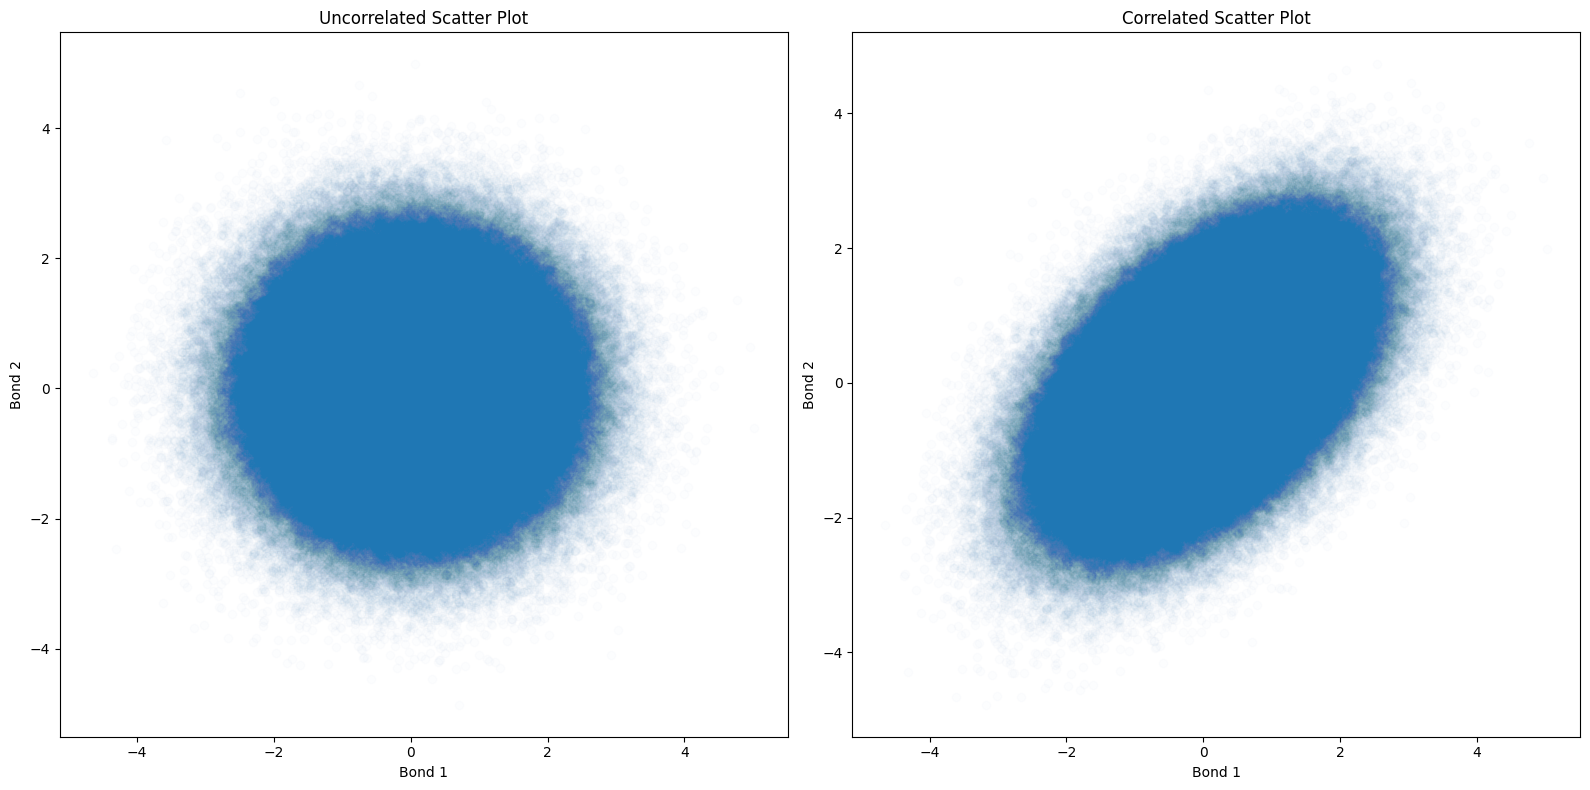

In [4]:
# Scatter Plots to observe correlation
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Uncorrelated Scatter Plot
axs[0].scatter(uncorrelated_probs_df['Bond 1'], uncorrelated_probs_df['Bond 2'], alpha=0.01)
axs[0].set_title('Uncorrelated Scatter Plot')
axs[0].set_xlabel('Bond 1')
axs[0].set_ylabel('Bond 2')

# Correlated Scatter Plot
axs[1].scatter(correlated_probs_df['Bond 1'], correlated_probs_df['Bond 2'], alpha=0.01)
axs[1].set_title('Correlated Scatter Plot')
axs[1].set_xlabel('Bond 1')
axs[1].set_ylabel('Bond 2')

plt.tight_layout()
plt.show()

## 5. Mapping simulated outcomes to bond values


In [5]:
bond_values_df = correlated_probs_df.copy()

# Mapping probabilities to corresponding bond values
for column in bond_values_df.columns:
    indices = np.digitize(bond_values_df[column], cumulative_probs)

    bond_values_df[column] = np.select(
        [indices == 8] + [indices == i for i in range(1, 8)],
        values,
        default=values[-1]
    )

bond_values_df.head()

,Bond 1,Bond 2
0,102.02,109.37
1,51.13,108.66
2,102.02,51.13
3,109.37,109.37
4,102.02,109.37


## 6. Portfolio value and P&L

In [6]:
# Determining the Portfolio Value and P&L
bond_values_df['portfolio_values'] = bond_values_df['Bond 1'] + bond_values_df['Bond 2']
bond_values_df['P&L'] = bond_values_df['portfolio_values'] - (n_bonds * BBB_face_value)

bond_values_df.head()

,Bond 1,Bond 2,portfolio_values,P&L
0,102.02,109.37,211.39,-3.71
1,51.13,108.66,159.79,-55.31
2,102.02,51.13,153.15,-61.95
3,109.37,109.37,218.74,3.64
4,102.02,109.37,211.39,-3.71


## 7. P&L distribution


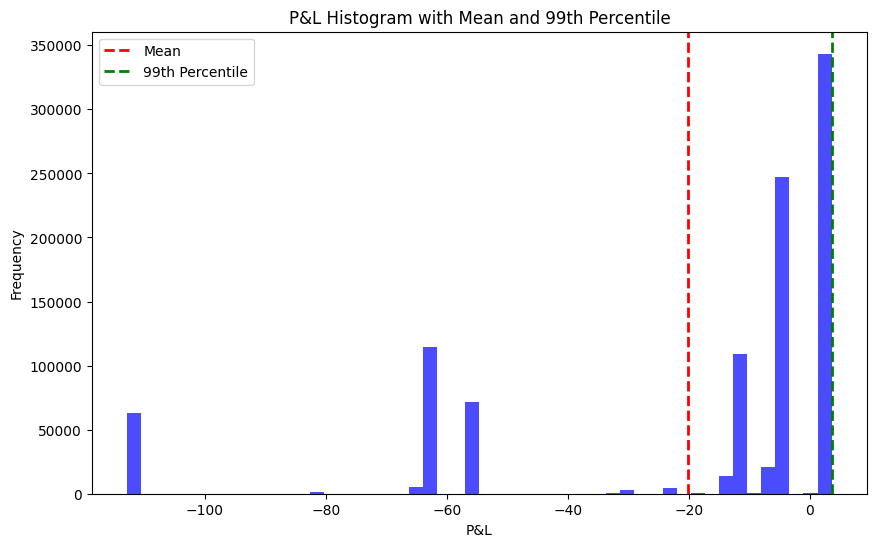

Mean P&L: -20.07
99th Percentile: 3.64


In [7]:
# Histogram of the "P&L" column
plt.figure(figsize=(10, 6))
plt.hist(bond_values_df['P&L'], bins=50, color='blue', alpha=0.7)

mean_pnl = bond_values_df['P&L'].mean()
percentile_99 = bond_values_df['P&L'].quantile(0.99)

plt.axvline(mean_pnl, color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(percentile_99, color='green', linestyle='dashed', linewidth=2, label='99th Percentile')
plt.xlabel('P&L')
plt.ylabel('Frequency')
plt.title('P&L Histogram with Mean and 99th Percentile')
plt.legend()
plt.show()

print(f"Mean P&L: {mean_pnl:.2f}")
print(f"99th Percentile: {percentile_99:.2f}")

## 8. Credit loss distribution

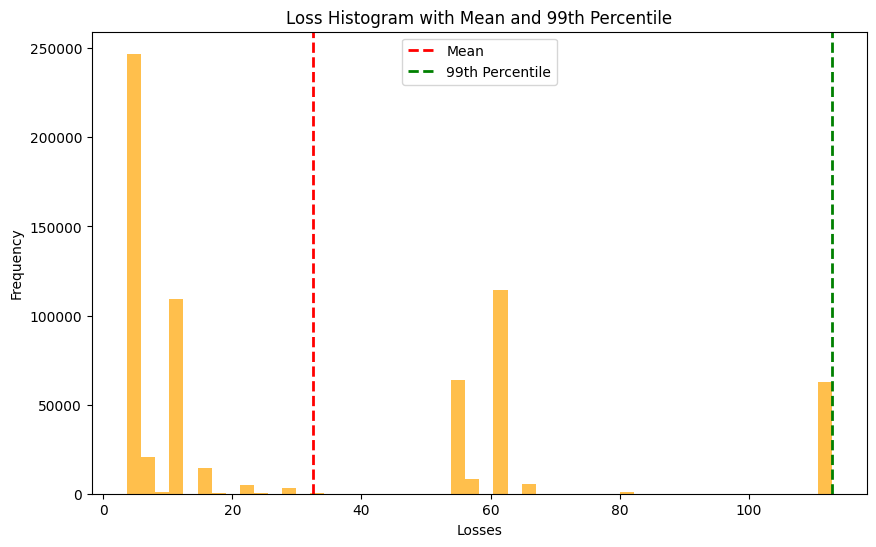

Expected Credit Loss: 32.46
99 VAR: 112.84


In [8]:
# Filtering negative P&L into an array
portfolio_losses = bond_values_df['P&L'][bond_values_df['P&L'] < 0].to_numpy()

# Converting Loss values to positive
portfolio_losses = np.abs(portfolio_losses)

# Histogram of the Losses
plt.figure(figsize=(10, 6))
plt.hist(portfolio_losses, bins=50, color='orange', alpha=0.7)

mean_portfolio_losses = portfolio_losses.mean()
portfolio_losses99 = np.percentile(portfolio_losses, 99)

plt.axvline(mean_portfolio_losses, color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(portfolio_losses99, color='green', linestyle='dashed', linewidth=2, label='99th Percentile')
plt.xlabel('Losses')
plt.ylabel('Frequency')
plt.title('Loss Histogram with Mean and 99th Percentile')
plt.legend()
plt.show()

print(f"Expected Credit Loss: {mean_portfolio_losses:.2f}")
print(f"99 VAR: {portfolio_losses99:.2f}")

## 9. Gaussian copula transformation

In [9]:
# GAUSSIAN COPULA WITH CORRELATION 0.5

# Converting correlated random variables to uniform variables using CDF
correlated_uniform_df = pd.DataFrame(norm.cdf(correlated_probs), columns=['Bond 1', 'Bond 2'])

correlation = correlated_uniform_df['Bond 1'].corr(correlated_uniform_df['Bond 2'])
print(f'Correlation between Bond 1 and Bond 2 in correlated_uniform_df: {correlation}')

Correlation between Bond 1 and Bond 2 in correlated_uniform_df: 0.48361489164271854


## 10. Visualize the Gaussian copula

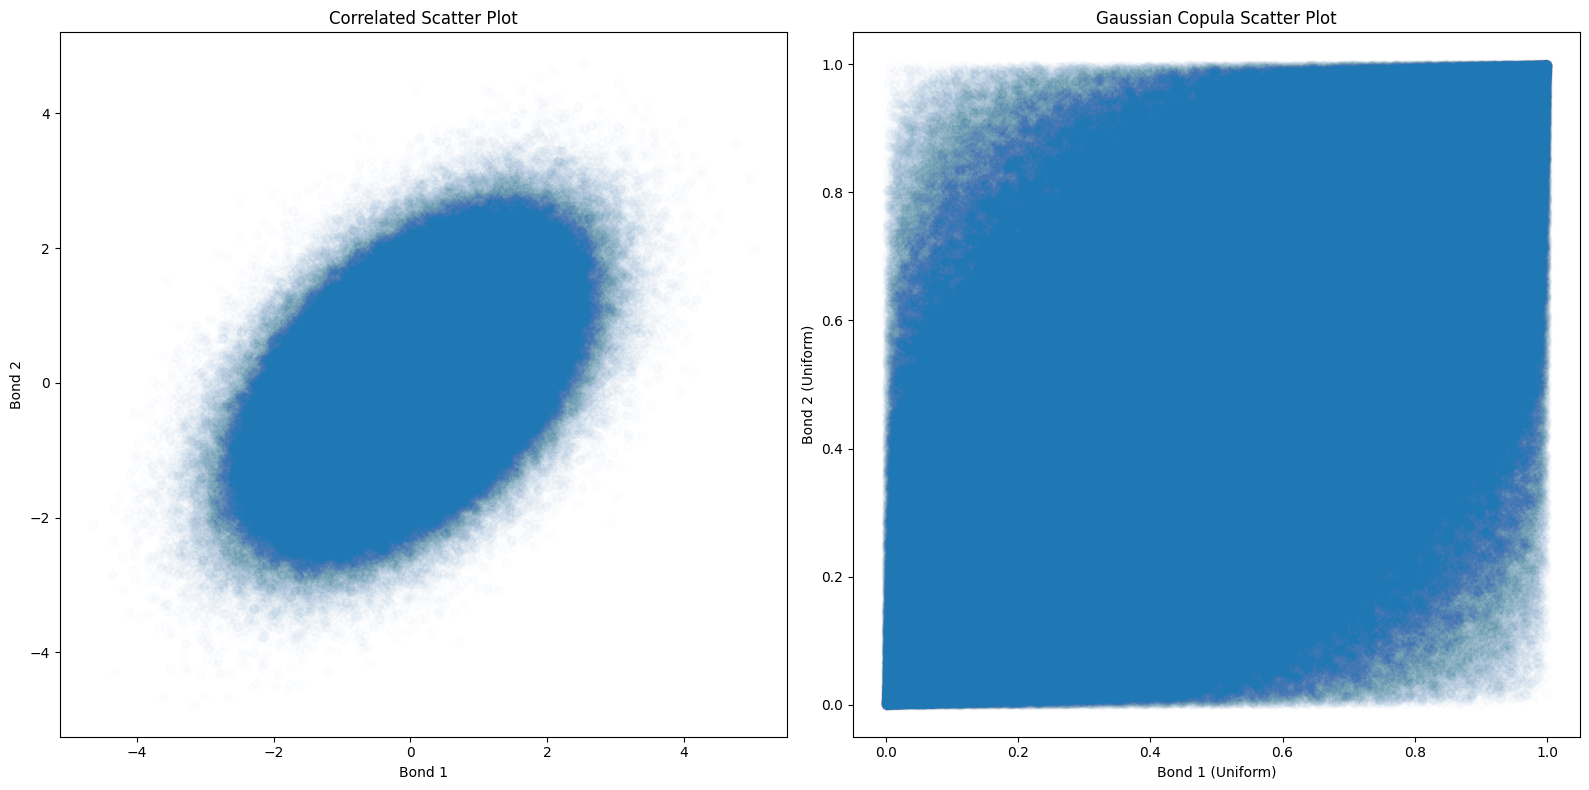

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Correlated Scatter Plot
axs[0].scatter(correlated_probs_df['Bond 1'], correlated_probs_df['Bond 2'], alpha=0.01)
axs[0].set_title('Correlated Scatter Plot')
axs[0].set_xlabel('Bond 1')
axs[0].set_ylabel('Bond 2')

# Correlated Uniform Scatter Plot
axs[1].scatter(correlated_uniform_df['Bond 1'], correlated_uniform_df['Bond 2'], alpha=0.01)
axs[1].set_title('Gaussian Copula Scatter Plot')
axs[1].set_xlabel('Bond 1 (Uniform)')
axs[1].set_ylabel('Bond 2 (Uniform)')

plt.tight_layout()
plt.show()

## 11. Map copula outcomes to bond values

In [11]:
# Mapping probabilities to corresponding bond values
for column in correlated_uniform_df.columns:
    indices = np.digitize(correlated_uniform_df[column], cumulative_probs)

    correlated_uniform_df[column] = np.select(
        [indices == 8] + [indices == i for i in range(1, 8)],
        values,
        default=values[-1]
    )

correlated_uniform_df.head()

,Bond 1,Bond 2
0,102.02,102.02
1,107.55,102.02
2,102.02,102.02
3,102.02,102.02
4,102.02,102.02


## 12. Copula portfolio value and P&L

In [12]:
copula_values_df = correlated_uniform_df.copy()

copula_values_df['portfolio_values'] = copula_values_df['Bond 1'] + copula_values_df['Bond 2']
copula_values_df['P&L'] = copula_values_df['portfolio_values'] - (n_bonds * BBB_face_value)

copula_values_df.head()

,Bond 1,Bond 2,portfolio_values,P&L
0,102.02,102.02,204.04,-11.06
1,107.55,102.02,209.57,-5.53
2,102.02,102.02,204.04,-11.06
3,102.02,102.02,204.04,-11.06
4,102.02,102.02,204.04,-11.06


## 13. Copula P&L distribution

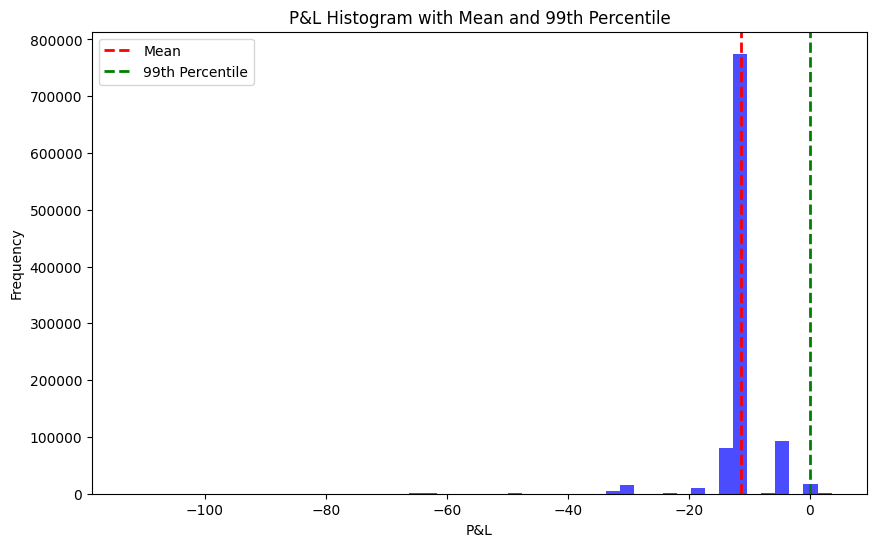

Mean P&L: -11.29
99th Percentile: 0.00


In [13]:
# Histogram of P&L (Gaussian Copula)
plt.figure(figsize=(10, 6))
plt.hist(copula_values_df['P&L'], bins=50, color='blue', alpha=0.7)

mean_pnl = copula_values_df['P&L'].mean()
percentile_99 = copula_values_df['P&L'].quantile(0.99)

plt.axvline(mean_pnl, color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(percentile_99, color='green', linestyle='dashed', linewidth=2, label='99th Percentile')

plt.xlabel('P&L')
plt.ylabel('Frequency')
plt.title('P&L Histogram with Mean and 99th Percentile')
plt.legend()
plt.show()

print(f"Mean P&L: {mean_pnl:.2f}")
print(f"99th Percentile: {percentile_99:.2f}")

## 14. Copula loss distribution

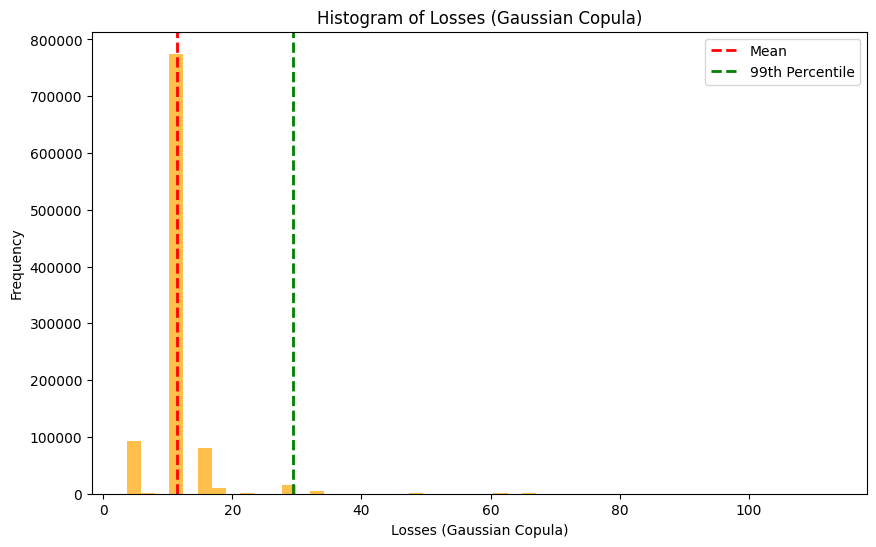

Expected Credit Loss (Gaussian Copula): 11.49
99 VAR (Gaussian Copula): 29.44


In [14]:
# Retrieving losses from P&L values
losses_copula = copula_values_df['P&L'][copula_values_df['P&L'] < 0]
losses_copula = np.abs(losses_copula.to_numpy())

# Histogram of Losses from the Gaussian Copula
plt.figure(figsize=(10, 6))
plt.hist(losses_copula, bins=50, color='orange', alpha=0.7)

mean_losses_copula = losses_copula.mean()
losses_copula99 = np.percentile(losses_copula, 99)

plt.axvline(mean_losses_copula, color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(losses_copula99, color='green', linestyle='dashed', linewidth=2, label='99th Percentile')
plt.xlabel('Losses (Gaussian Copula)')
plt.ylabel('Frequency')
plt.title('Histogram of Losses (Gaussian Copula)')
plt.legend()
plt.show()

print(f"Expected Credit Loss (Gaussian Copula): {mean_losses_copula:.2f}")
print(f"99 VAR (Gaussian Copula): {losses_copula99:.2f}")